# Cybersecurity Gradient Boosting Hyperparameter Tuning

**Author:** Usha Priya Krishnasamy  
**Project Type:** Gradient boosting classification, hyperparameter tuning, feature importance, and model evaluation  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15

The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Project Overview

This notebook applies Gradient Boosting classification across three cybersecurity datasets used for threat detection, anomaly analysis, and attack classification.

The workflow includes adaptive sampling, model training, hyperparameter tuning using GridSearchCV, evaluation with precision, recall, F1-score, ROC-AUC, confusion matrices, and feature-importance review.

This notebook is included in the modeling folder because it focuses on supervised boosting models, parameter tuning, and cybersecurity classification performance.

#### Note

The raw datasets are not included in this repository. The analysis was developed using public cybersecurity datasets.

Adaptive sampling is used for selected experiments to reduce runtime on large cybersecurity datasets.

In [ ]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

   
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
########################## Week 8 libraires for KNN ######################33333333
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
 

random_state = 0
 ## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\24
['cybersecurity_attacks.csv', 'README.md']


# 1.BETH dataset

In [7]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)

########################################## adaptive sampling ############################################################3
# ================================================
# WEEK 6: Decision Trees and Random Forests (ADAPTIVE SAMPLE)
# Author: Usha Priya Krishnasamy
# Dataset: BETH (Target = evil)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Encode categorical features
# ============================================================

numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])

# ============================================================
# Train-Validation-Test Split
# ============================================================

df_train_val, df_test = train_test_split(
    df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42
)
df_beth, df_val = train_test_split(
    df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42
)

print(f" Train shape: {df_beth.shape}, Validation shape: {df_val.shape}, Test shape: {df_test.shape}")

# ============================================================
# Data Cleaning Check
# ============================================================

print(f"Null values:\n{df_beth.isnull().sum()}")
print(f"Shape of training data: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print(f"Numeric columns:\n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"Categorical columns:\n{categorical_columns_beth}")

# ============================================================
#  Feature and Target Assignment
# ============================================================

X_train_beth = df_beth.drop(['evil', 'sus'], axis=1)
y_train_beth = df_beth['evil']

X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']

# ============================================================
# Regularization and Normalization
# ============================================================





regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

norm = MinMaxScaler()
X_train_beth_norm = norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# ============================================================
# Adaptive Sampling (for Week 6 Experiments)
# ============================================================

total_rows = df_beth_merged.shape[0]

# If large dataset (>20k rows), take 5%; else up to 1000 rows
if total_rows > 20000:
    sample_size = int(total_rows * 0.05)
else:
    sample_size = min(1000, total_rows)

df_beth_sample = df_beth_merged.sample(n=sample_size, random_state=42)

print(f"\nAdaptive sample size selected: {sample_size} rows from {total_rows} total")

 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')
 Train shape: (684646, 16), Validation shape: (228216, 16), Test shape: (228216, 16)
Null values:
timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0


 Adaptive Sample Shapes → Train: (45642, 14), Test: (11411, 14)
Class distribution:
 evil
0    0.859581
1    0.140419
Name: proportion, dtype: float64


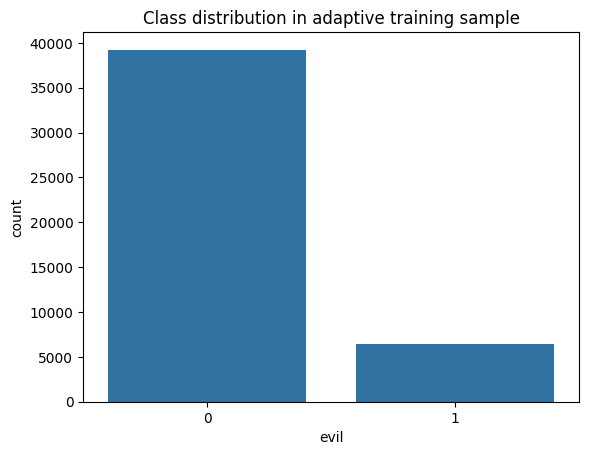

CV F1 scores: [0.99960983 0.99921936 0.99961014 0.99882858 0.99921936]
Mean CV F1: 0.9992974542030446
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1: 0.999765838396805

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9809
           1       1.00      1.00      1.00      1602

    accuracy                           1.00     11411
   macro avg       1.00      1.00      1.00     11411
weighted avg       1.00      1.00      1.00     11411



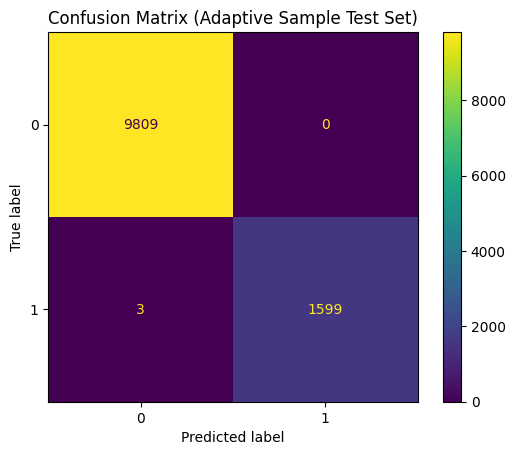

Test ROC AUC: 0.9993371523438499


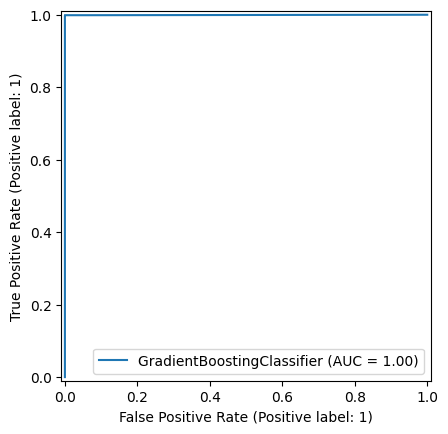

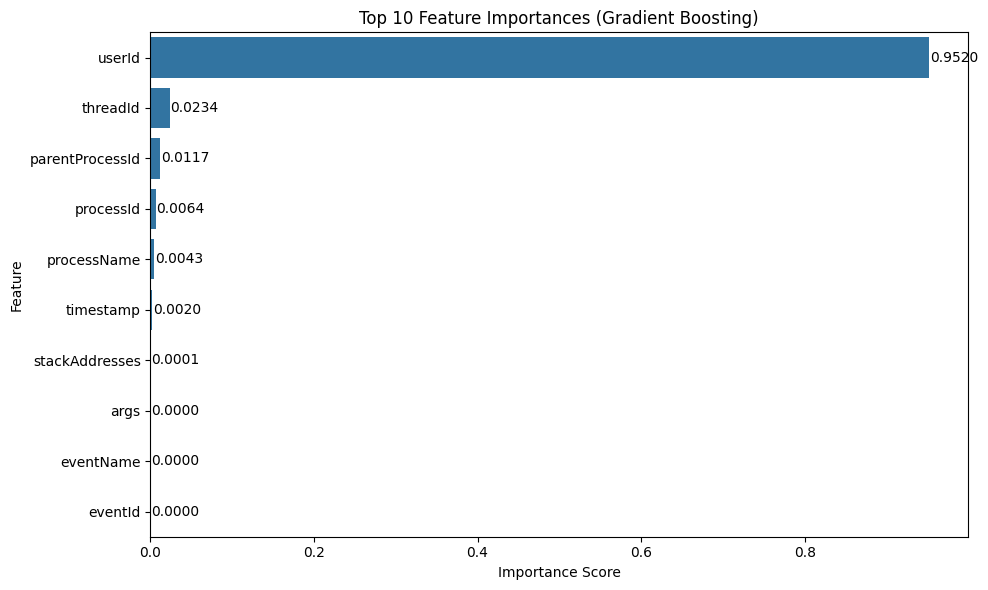

In [8]:
#============================================================
# Gradient Boosting Classification on BETH Dataset (Adaptive Sample)
#============================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
classification_report, confusion_matrix, ConfusionMatrixDisplay,
roc_auc_score, RocCurveDisplay
)
 
#============================================================
#Step 1: Prepare adaptive sample for modeling
#============================================================
#Ensure sample uses same feature-target structure as main dataset
X_beth_sample = df_beth_sample.drop(['evil', 'sus'], axis=1)
y_beth_sample = df_beth_sample['evil']
#Regularize the features
regularize = StandardScaler()
X_beth_sample_reg = regularize.fit_transform(X_beth_sample)
#Split into train/test subsets (small ones)
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
X_beth_sample_reg, y_beth_sample, test_size=0.2, stratify=y_beth_sample, random_state=42
)
print(f" Adaptive Sample Shapes → Train: {X_train_small.shape}, Test: {X_test_small.shape}")
print("Class distribution:\n", y_train_small.value_counts(normalize=True))
#Quick visual check
sns.countplot(x=y_train_small)
plt.title("Class distribution in adaptive training sample")
plt.show()
#============================================================
#Step 2: Gradient Boosting Baseline
#============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
scores = cross_val_score(gb, X_train_small, y_train_small, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores:", scores)
print("Mean CV F1:", np.mean(scores))
#============================================================
# Step 3: Grid Search for Hyperparameter Tuning (smaller grid for speed)
#============================================================
param_grid = {
'n_estimators': [50, 100, 150],
'learning_rate': [0.01, 0.1, 0.2],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0],  # Regularization via subsampling
'min_samples_split': [2, 5]  # Regularization to prevent overfitting
}
grid = GridSearchCV(gb, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid.fit(X_train_small, y_train_small)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)
#============================================================
# 4: Evaluate on Test Split
#============================================================
best_gb = grid.best_estimator_
y_pred = best_gb.predict(X_test_small)
print("\nClassification Report:\n", classification_report(y_test_small, y_pred))
cm = confusion_matrix(y_test_small, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Adaptive Sample Test Set)")
plt.show()
#ROC-AUC
y_proba = best_gb.predict_proba(X_test_small)[:, 1]
print("Test ROC AUC:", roc_auc_score(y_test_small, y_proba))
RocCurveDisplay.from_estimator(best_gb, X_test_small, y_test_small)
plt.show()
#============================================================
# Step 5: Feature Importance (for interpretability)
#============================================================
importances = pd.DataFrame({
    'feature': X_beth_sample.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='importance', y='feature', data=importances.head(10))

# --- Add annotation on each bar ---
for i, v in enumerate(importances.head(10)['importance']):
    ax.text(
        v + 0.001,                     # Position slightly to the right of bar
        i,                             # y-position (bar index)
        f"{v:.4f}",                    # Text format
        color='black',
        va='center'
    )

plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### BETH Dataset Findings

The BETH dataset showed very strong Gradient Boosting performance on the adaptive sample.

GridSearchCV selected a tuned model with learning rate, tree depth, number of estimators, subsampling, and split-size parameters. The model achieved very high cross-validation F1-score and strong ROC-AUC on the test split.

The feature-importance plot shows that selected process, user, event, argument, and system-behavior features contributed strongly to malicious-activity detection.

Because the results are based on an adaptive sample, they should be interpreted as portfolio-scale modeling results rather than production-ready cybersecurity validation.

# 2.Cybersecurity Attacks dataset

In [9]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)



CV F1 scores: [0.99592093 0.99544812 0.99639329 0.99552696 0.99536928]
Mean CV F1: 0.9957317155437309
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.8}
Best Cross-Validation F1: 0.9974466203889923

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.99      1.00      1.00      7957

    accuracy                           0.99      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      0.99      0.99      8000



c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

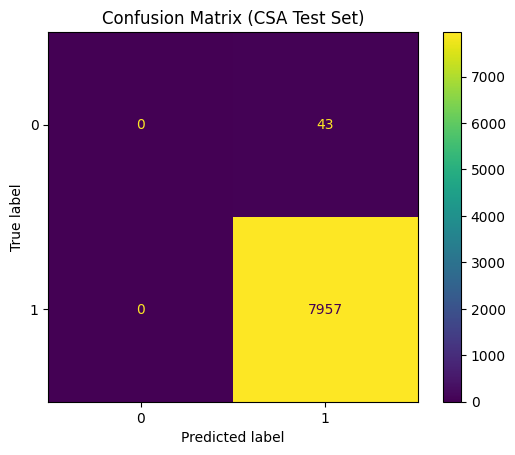

Test ROC-AUC Score: 0.48544648415465685


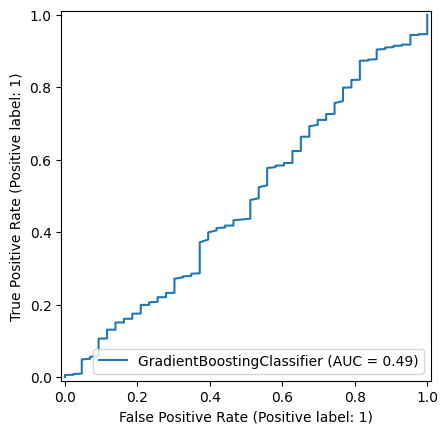

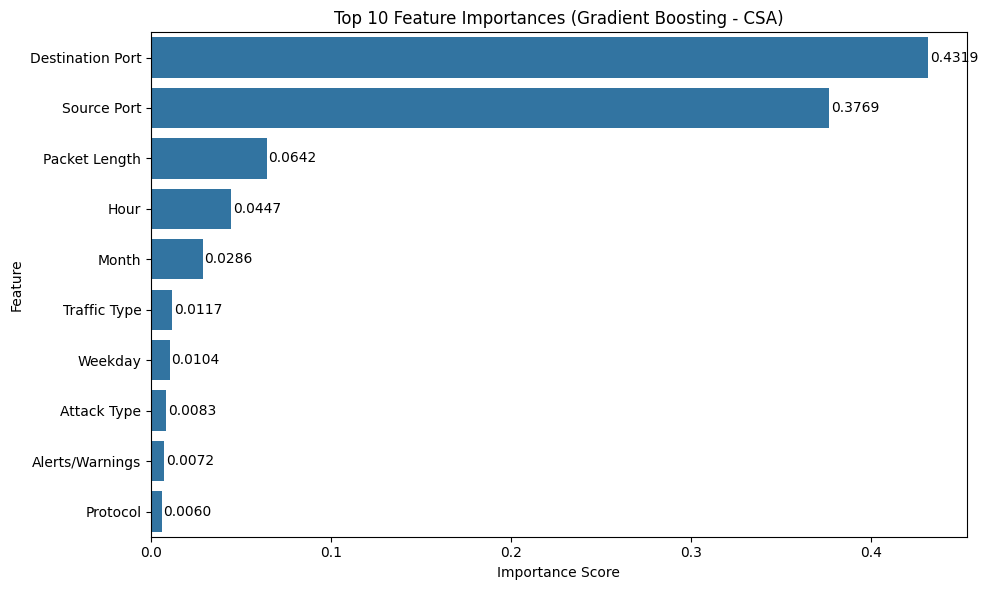

In [ ]:
#Step 1: Gradient Boosting Baseline
#============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_csa = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
scores = cross_val_score(gb_csa, X_train_csa_reg, y_train_csa, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores:", scores)
print("Mean CV F1:", np.mean(scores))
#============================================================
# Step 2: Hyperparameter Tuning (Grid Search)
#============================================================
param_grid = {
'n_estimators': [50, 100, 150],
'learning_rate': [0.01, 0.1, 0.2],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0],
'min_samples_split': [2, 5]
}
grid_csa = GridSearchCV(gb_csa, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid_csa.fit(X_train_csa_reg, y_train_csa)
print("\nBest Parameters:", grid_csa.best_params_)
print("Best Cross-Validation F1:", grid_csa.best_score_)
#============================================================
# Step 3: Evaluate on Test Set
#============================================================
best_gb_csa = grid_csa.best_estimator_
y_pred_csa = best_gb_csa.predict(X_test_csa_reg)
print("\nClassification Report:\n", classification_report(y_test_csa, y_pred_csa))
cm = confusion_matrix(y_test_csa, y_pred_csa)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (CSA Test Set)")
plt.show()
#ROC-AUC
y_proba_csa = best_gb_csa.predict_proba(X_test_csa_reg)[:, 1]
roc_auc = roc_auc_score(y_test_csa, y_proba_csa)
print("Test ROC-AUC Score:", roc_auc)
RocCurveDisplay.from_estimator(best_gb_csa, X_test_csa_reg, y_test_csa)
plt.show()
#============================================================
#Step 4: Feature Importance
#============================================================
importances_csa = pd.DataFrame({
    'feature': X_train_csa.columns,
    'importance': best_gb_csa.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='importance', y='feature', data=importances_csa.head(10))

# --- Annotate each bar with the importance score ---
for i, v in enumerate(importances_csa.head(10)['importance']):
    ax.text(
        v + 0.001,        # slight offset to the right of the bar
        i,                # vertical position aligned with bar index
        f"{v:.4f}",       # value rounded to 4 decimals
        color='black',
        va='center'
    )

plt.title("Top 10 Feature Importances (Gradient Boosting - CSA)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### Cybersecurity Attacks Dataset Findings

The Cybersecurity Attacks dataset required target engineering because `Anomaly Scores` are continuous.

Gradient Boosting performed well for the majority class, but the model struggled with the minority class. This shows that high accuracy and high weighted F1-score can be misleading when one class dominates the target distribution.

The ROC-AUC and classification report are more informative than accuracy for this dataset.

Overall, CSA is useful for testing the Gradient Boosting pipeline, but class imbalance must be handled carefully before using it for final cybersecurity model evaluation.

# 3.UNSW-NB15 Intrusion Detection dataset

In [ ]:
from sklearn.impute import SimpleImputer

# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)


# =======================================================
#  Adaptive Sampling on Training Set with NaN handling
# =======================================================
total_rows_train = X_train_unsw_reg_df.shape[0]

# Determine sample size
if total_rows_train > 20000:
    sample_size_train = int(total_rows_train * 0.05)
else:
    sample_size_train = min(1000, total_rows_train)

# Sample training set
sampled = X_train_unsw_reg_df.join(y_train).sample(n=sample_size_train, random_state=42)
target_col = y_train.name

# Drop rows where target is NaN
sampled = sampled.dropna(subset=[target_col])

# Separate features and target
X_train_sample = sampled.drop(columns=target_col)
y_train_sample = sampled[target_col]

# Handle NaNs in features (if any) by replacing with median
imputer = SimpleImputer(strategy='median')
X_train_sample = pd.DataFrame(imputer.fit_transform(X_train_sample), columns=X_train_sample.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_unsw_reg_df), columns=X_test_unsw_reg_df.columns)

print(f"Adaptive sample size after dropping NaNs: {X_train_sample.shape[0]} rows from {total_rows_train} training rows")


Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')
✅ Adaptive sample size after dropping NaNs: 8268 rows from 206138 training rows


CV F1 scores (sampled training set): [0.81850789 0.81481481 0.82007168 0.81935484 0.81412104]
Mean CV F1: 0.817374053307509
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation F1 (sampled): 0.8200443677859607

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.00      0.01     18653
           1       0.64      1.00      0.78     32882

    accuracy                           0.64     51535
   macro avg       0.71      0.50      0.39     51535
weighted avg       0.69      0.64      0.50     51535



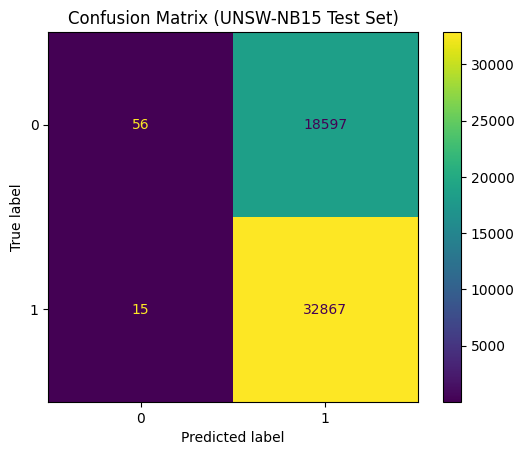

Test ROC-AUC Score: 0.7047579963689974


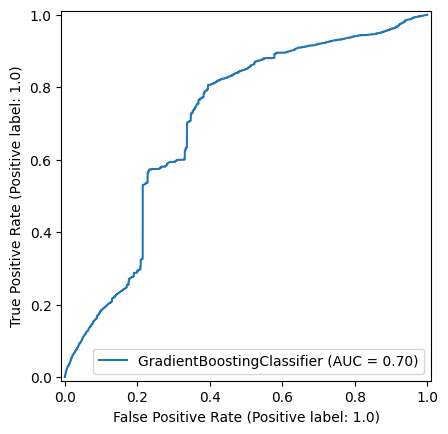

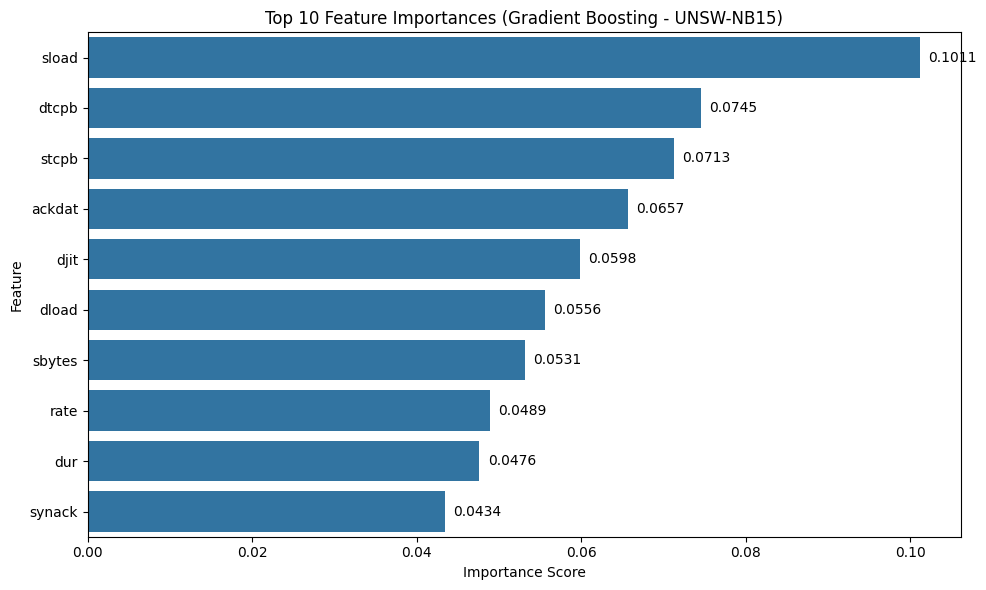

In [ ]:
#============================================================
# Step 1: Gradient Boosting Baseline using sampled training set
#============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_unsw = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
#Use the adaptive sample
scores = cross_val_score(gb_unsw, X_train_sample, y_train_sample, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores (sampled training set):", scores)
print("Mean CV F1:", np.mean(scores))
#============================================================
# Step 2: Hyperparameter Tuning (Grid Search) on sampled training set
#============================================================
param_grid = {
'n_estimators': [50, 100, 150],
'learning_rate': [0.01, 0.1, 0.2],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0],
'min_samples_split': [2, 5]
}
grid_unsw = GridSearchCV(gb_unsw, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid_unsw.fit(X_train_sample, y_train_sample)
print("\nBest Parameters:", grid_unsw.best_params_)
print("Best Cross-Validation F1 (sampled):", grid_unsw.best_score_)
#============================================================
#Step 3: Evaluate on Test Set
#============================================================
best_gb_unsw = grid_unsw.best_estimator_
y_pred_unsw = best_gb_unsw.predict(X_test_clean)  # Use the NaN-handled test set
print("\nClassification Report:\n", classification_report(y_test, y_pred_unsw))
cm = confusion_matrix(y_test, y_pred_unsw)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (UNSW-NB15 Test Set)")
plt.show()
#ROC-AUC
y_proba_unsw = best_gb_unsw.predict_proba(X_test_clean)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_unsw)
print("Test ROC-AUC Score:", roc_auc)
RocCurveDisplay.from_estimator(best_gb_unsw, X_test_clean, y_test)
plt.show()
#============================================================
#Step 4: Feature Importance
#============================================================
importances_unsw = pd.DataFrame({
    'feature': X_train_sample.columns,
    'importance': best_gb_unsw.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='importance', y='feature', data=importances_unsw.head(10))

# --- Annotate each bar with importance score ---
for i, v in enumerate(importances_unsw.head(10)['importance']):
    ax.text(
        v + 0.001,     # slight offset to the right of the bar
        i,             # y-position at bar index
        f"{v:.4f}",    # format value
        color='black',
        va='center'
    )

plt.title("Top 10 Feature Importances (Gradient Boosting - UNSW-NB15)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### UNSW-NB15 Dataset Findings

The UNSW-NB15 dataset was tested using Gradient Boosting on an adaptive training sample.

The model showed strong recall for attack traffic, but it performed poorly on the normal class in the test set. This suggests that the model became biased toward predicting attack records.

Although cross-validation performance on the sampled training data was reasonable, the test results show weaker generalization. A larger training sample, class balancing, and more careful hyperparameter tuning may improve performance.

Overall, UNSW-NB15 remains a strong dataset for intrusion detection, but this Gradient Boosting version should be interpreted as a baseline experiment rather than the final best model.

#### Overall Gradient Boosting Conclusion

Across the three cybersecurity datasets, Gradient Boosting provided a useful supervised classification baseline.

BETH produced the strongest results, showing that host-level process, user, event, argument, and system-behavior features contain strong signal for malicious activity detection.

The Cybersecurity Attacks dataset should be interpreted cautiously because anomaly-score thresholding and class imbalance can make accuracy misleading.

UNSW-NB15 showed that Gradient Boosting can detect attack traffic, but the model struggled with normal-class recall in this sampled experiment.

Overall, this notebook shows that Gradient Boosting is a strong candidate for cybersecurity threat detection, but final evaluation should rely on recall, F1-score, ROC-AUC, confusion matrices, and class-specific performance rather than accuracy alone.